# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [ ]:
# importar librerías
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
ord_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [ ]:
# mostrar información del DataFrame
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [ ]:
# mostrar información del DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
# mostrar información del DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
# mostrar información del DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [ ]:
# mostrar información del DataFrame
ord_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

- Los datos de todas las tablas predomina el formato entero y de texto. \n
- Se manejan 49,694 productos diferentes. \n
- Se vendieron 4,545,007 productos en total en 478,967 ordenes diferentes.  \n
- El almacenamiento de los productos esta dividido en departamentos que a su vez están organizados por pasillos. \n


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.
- Revisar y corregir (en caso de ser necesario) las columnas que contengan valores ausentes o duplicados con las funciones \n
    .isna().sum() y duplicated().sum() para realizar la busqueda, .dropna() para corregir valores ausentes y drop_duplicates() \n para eliminar los valores duplicados. \n


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [ ]:
# Revisa si hay pedidos duplicados
print(orders.duplicated().sum())
print()
print(orders[orders.duplicated()])

15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48        

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Si, tengo 15. Todos son pedidos del miércoles a las 2am.

In [ ]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
wednesday2 = orders[(orders['order_dow']==3) & (orders['order_hour_of_day']==2)]
print(wednesday2)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado?
Poco más del 10% de los datos de este horario están duplicados.

In [ ]:
# Elimina los pedidos duplicados
orders.drop_duplicates(inplace=True)
orders.reset_index()

,index,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,0,1515936,183418,11,6,13,30.0
1,1,1690866,163593,5,5,12,9.0
2,2,1454967,39980,4,5,19,2.0
3,3,1768857,82516,56,0,20,10.0
4,4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...,...
478947,478962,3210681,5617,5,1,14,7.0
478948,478963,3270802,112087,2,3,13,6.0
478949,478964,885349,82944,16,2,11,6.0
478950,478965,216274,4391,3,3,8,8.0


In [ ]:
# Vuelve a verificar si hay filas duplicadas
print(orders.duplicated().sum())

0


In [ ]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos

print(orders.duplicated().sum())
print()

print(orders[orders.duplicated()])

0

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos
-Elimine 15 órdenes que encontré duplicadas del día miércoles a las 2 am.

### `products` data frame

In [ ]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())
print()
print(products[products.duplicated()])

0

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [ ]:
# Revisa únicamente si hay ID de productos duplicados
print(products[products.duplicated(subset='product_id')])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [ ]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

new_names = []
for prod in products:
    name_uppered = prod.upper()
    new_names.append(name_uppered)
product_name = new_names


In [ ]:
# Revisa si hay nombres duplicados de productos no faltantes
print(products.duplicated().sum())
print()
print(products[products.duplicated(subset='product_id')])

0

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos. \n
En la busqueda de valores duplicados en el dataset de productos no encontre ningun valor duplicado aún después de convertir los nombres a mayúsculas.

### `departments` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())
print()
print(departments[departments.duplicated()])

0

Empty DataFrame
Columns: [department_id, department]
Index: []


In [ ]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments[departments.duplicated(subset='department_id')])

Empty DataFrame
Columns: [department_id, department]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Al igual que con el dataset de products, en departments no encontré valores duplicados.

### `aisles` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas

print(aisles.duplicated().sum())
print()
print(aisles[aisles.duplicated()])


0

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


In [ ]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles[aisles.duplicated(subset='aisle_id')])

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Al igual que con el dataset de products y departments, en aisles no encontré valores duplicados.

### `order_products` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print(ord_products.duplicated().sum())
print()
print(ord_products[ord_products.duplicated()])

0

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [ ]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(ord_products.duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
En este dataframe no hay valores duplicados por lo que en este sentido no hay nada que hacer, veremos luego si en valores ausentes encontramos algo.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [ ]:
# Encuentra los valores ausentes en la columna 'product_name'
print(products.isna().sum())
null = products[products.isna().any(axis=1)]
print(null)

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64
       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.
- Hay 1258 productos con nombre None o NaN, pertenecientes al departamento 21 y pasillo #100.

In [ ]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print(null['aisle_id'].unique())

[100]


Describe brevemente cuáles son tus hallazgos.
- Si, todos los productos con nombre ausente pertenecen al pasillo #100.

In [ ]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(null['department_id'].unique())

[21]


Describe brevemente cuáles son tus hallazgos.
- Si, todos los productos con nombre ausente pertenecen al departamento 21.

In [ ]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
name_21 = departments[departments['department_id'] == 21]
print(name_21)
name_100 = aisles[aisles['aisle_id'] == 100]
print(name_100)

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


Describe brevemente cuáles son tus hallazgos.
- El nombre en ambas tablas es 'perdido'.

In [ ]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].isna().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Se cambio el nombre a los valores ausentes por lo que ahora al buscarlos el resultado es 0.

### `orders` data frame

In [ ]:
# Encuentra los valores ausentes
print(orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [ ]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
null2 = orders[orders['days_since_prior_order'].isna()]
print(null2['order_number'].unique())

[1]


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- No, todos son clientes nuevos.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Identificaste correctamente que los valores ausentes en `days_since_prior_order` corresponden a `order_number == 1`! Dejar los valores como `NaN` o usar un valor razonable asegura que los datos se manejen correctamente.

</div>

### `order_products` data frame

In [ ]:
# Encuentra los valores ausentes
print(ord_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [ ]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(ord_products['add_to_cart_order'].min())
print(ord_products['add_to_cart_order'].max())

1.0
64.0


Describe brevemente cuáles son tus hallazgos.
- El pedido mínimo lleva 1 producto.
- El pedido máximo lleva 64 productos.

In [ ]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_ids = ord_products.loc[ord_products['add_to_cart_order'].isna()]
print(missing_ids)

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [ ]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
nan_ord = ord_products[ord_products.isna().any(axis=1)]
products_by_ord = ord_products.groupby('order_id')['add_to_cart_order'].count()
print(products_by_ord)
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.

group_nan_ord = nan_ord.groupby('order_id')
print(group_nan_ord.size())
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
products_count = ord_products.groupby("order_id")["product_id"].count()
print(products_count.min())

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: add_to_cart_order, Length: 450046, dtype: int64
order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Length: 70, dtype: int64
1


Describe brevemente cuáles son tus hallazgos.
- No todos los pedidos con valores ausentes tienen 64 productos.
- También hay compras en las que solo se adquirio un producto.

In [ ]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
ord_products['add_to_cart_order'] = ord_products['add_to_cart_order'].fillna(999)
ord_products['add_to_cart_order'] = ord_products['add_to_cart_order'].astype('int64')


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Se cambiaron los valores ausentes por 999.
- Se cambio a enteros la columna 'add_to_cart_order'.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos
- Es importante revisar todos los datasets con los que vaya a trabajar para no tener análisis erroneos
- Los errores más comunes en los datasets son valores ausentes y valores duplicados.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [ ]:
valid_day = orders['order_hour_of_day'].unique()
valid_days = sorted(valid_day)
print(valid_days)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [ ]:
valid_hour = orders['order_dow'].unique()
valid_hours = sorted(valid_hour)
print(valid_hours)

[0, 1, 2, 3, 4, 5, 6]


Escribe aquí tus conclusiones
- Los datos en la tabla orders si están en parámetros razonables.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_number, dtype: int64


array([[<AxesSubplot:title={'center':'order_hour_of_day'}>]], dtype=object)

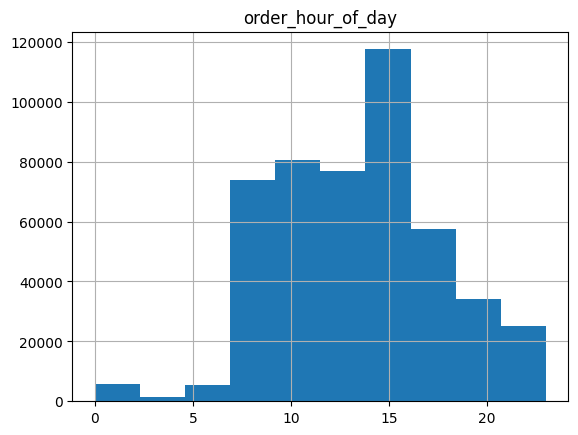

In [ ]:
ord_by_hour = orders.groupby('order_hour_of_day')['order_number'].count()
print(ord_by_hour)
orders.hist(column='order_hour_of_day')

Escribe aquí tus conclusiones
- De 10 a 11 son las horas pico.
- De 10 a 17 son horas con alta demanda.
- De 18 a 4 del día siguiente el descenso de pedidos es consistente.
- A las 4 es la hora en que menos pedido se reciben.

### [A3] ¿Qué día de la semana compran víveres las personas?

order_dow
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_number, dtype: int64


array([[<AxesSubplot:title={'center':'order_dow'}>]], dtype=object)

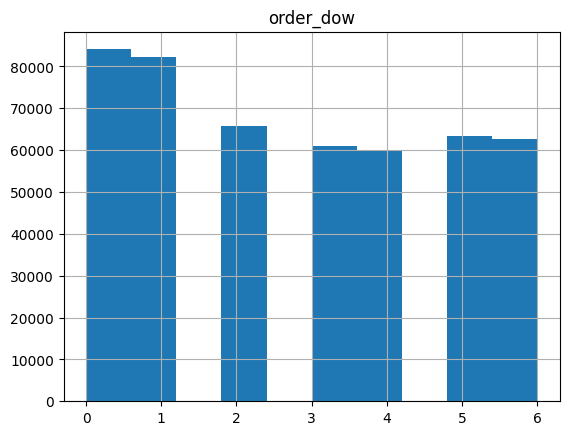

In [ ]:
ord_by_day = orders.groupby('order_dow')['order_number'].count()
print(ord_by_day)
orders.hist(column='order_dow')

Escribe aquí tus conclusiones
- El domingo es el día con más ventas seguido del lunes.
- El jueves es el día con menos ventas.
- El sábado es el día del fin de semana que menos se vende.
-

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

0.0
30.0
11.101813900274362


array([[<AxesSubplot:title={'center':'days_since_prior_order'}>]],
      dtype=object)

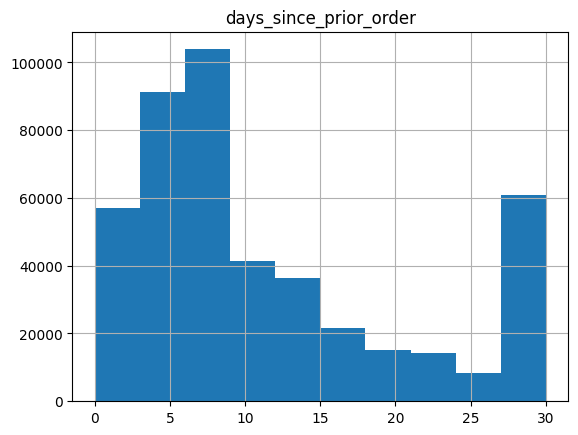

In [ ]:
print(orders['days_since_prior_order'].min())
print(orders['days_since_prior_order'].max())
print(orders['days_since_prior_order'].mean())
orders.hist(column='days_since_prior_order')

Escribe aquí tus conclusiones
- Hay personas que realizan varias compras el mismo día (mín=0)
- Hay personas que se esperan un mes para volver a comprar (max=30)
- El tiempo promedio para volver a comprar es de 11 días.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [ ]:
# Filtrar órdenes de miércoles y sábado
wend = orders[orders['order_dow'] == 3]
sat = orders[orders['order_dow'] == 6]

In [ ]:
# Agrupar las órdenes por hora
wend_group = wend.groupby(by='order_hour_of_day')['order_dow'].count()
sat_group = sat.groupby(by='order_hour_of_day')['order_dow'].count()

In [ ]:
# Unir las tablas
wend_sat = pd.concat([wend_group, sat_group], axis=1, keys=['miercoles', 'sabado'])
print(wend_sat)

                   miercoles  sabado
order_hour_of_day                   
0                        373     464
1                        215     254
2                        106     177
3                        101     125
4                        108     118
5                        170     161
6                        643     451
7                       1732    1619
8                       3125    3246
9                       4490    4311
10                      5026    4919
11                      5004    5116
12                      4688    5132
13                      4674    5323
14                      4774    5375
15                      5163    5188
16                      4976    5029
17                      4175    4295
18                      3463    3338
19                      2652    2610
20                      1917    1847
21                      1450    1473
22                      1154    1185
23                       718     893


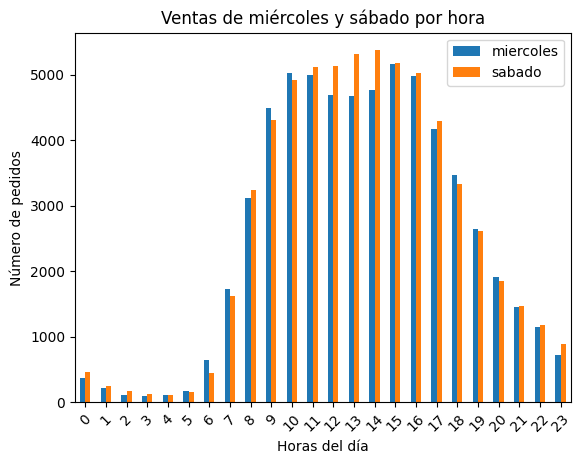

In [ ]:
# Graficar la tabla
wend_sat.plot(title= 'Ventas de miércoles y sábado por hora', kind='bar',
             xlabel="Horas del día", ylabel="Número de pedidos",
             rot=45)
plt.show()

Escribe aquí tus conclusiones
- De 12am a 3:59am hay más pedidos el miércoles.
- De 11am a 5:59pm hay más pedidos el sábado.
- Es más marcada la diferencia las horas que se vende más los sábados que los miércoles.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [ ]:
ord_by_num = orders.groupby(by='order_number')['order_dow'].count()

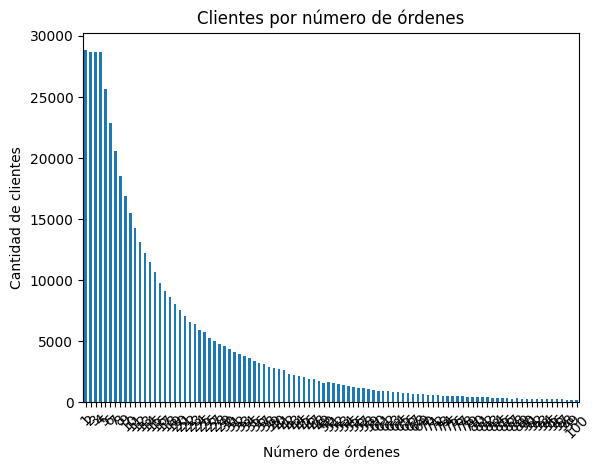

<Figure size 1400x600 with 0 Axes>

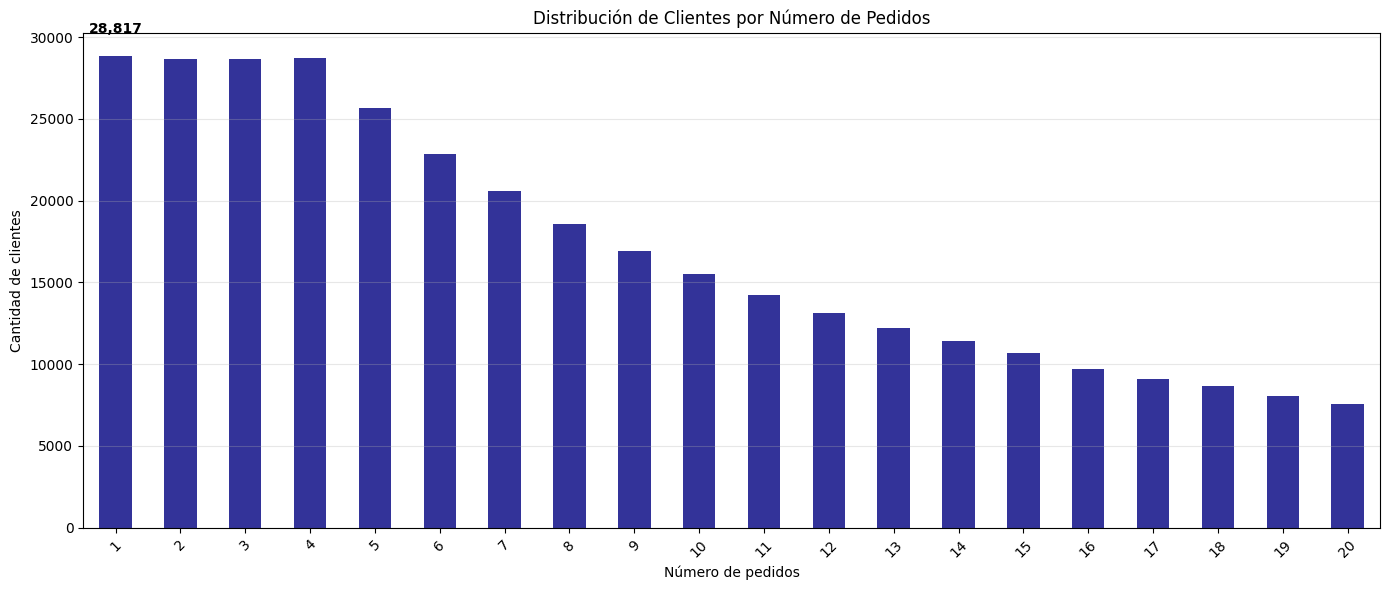

In [ ]:
# Gráfica con todos los clientes por número de pedidos
ord_by_num.plot(title= 'Clientes por número de órdenes', kind='bar',
             xlabel="Número de órdenes", ylabel="Cantidad de clientes",
             rot=45)
plt.figure(figsize=(14, 6))
plt.tight_layout()

plt.figure(figsize=(14, 6))
ax = ord_by_num.head(20).plot(kind='bar',
                              title='Distribución de Clientes por Número de Pedidos',
                              xlabel="Número de pedidos",
                              ylabel="Cantidad de clientes",
                              rot=45,
                              color='navy',
                              alpha=0.8)

# Agregar valor en la barra más alta
max_value = ord_by_num.head(50).max()
max_index = ord_by_num.head(50).idxmax()
ax.annotate(f'{max_value:,}',
            xy=(0, max_value),
            xytext=(0, max_value + max_value*0.05),
            ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones
- La mayoría de los clientes hacen entre 1 y 4 compras.
- A partir de la 5 compra empieza un descenso exponencial en las compras.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [ ]:

pop_products = ord_products.groupby("product_id")["order_id"].count().reset_index()
pop_products.columns = ['product_id', 'order_count']
pop_products = pop_products.sort_values('order_count', ascending=False)


In [ ]:

pop_names = pop_products.merge(products[['product_id', 'product_name']],
                                  on='product_id',
                                  how='left')


In [ ]:
print(pop_names[['product_id', 'product_name']].head(20))

    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        47626               Large Lemon
7        16797              Strawberries
8        26209                     Limes
9        27845        Organic Whole Milk
10       27966       Organic Raspberries
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       39275       Organic Blueberries
15       49683            Cucumber Kirby
16       28204        Organic Fuji Apple
17        5876             Organic Lemon
18        8277  Apple Honeycrisp Organic
19       40706    Organic Grape Tomatoes


Escribe aquí tus conclusiones
- Todos los productos son materias primas para preparar otras comidas.
- La mayoría de los productos son frutas y verduras.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [ ]:
products_by_order = ord_products.groupby(by='order_id')['product_id'].count() # Agrupar productos por cada órden

In [ ]:
print(products_by_order.max())
print(products_by_order.min())
print(ord_products['add_to_cart_order'].mean())

127
1
8.533887406554049


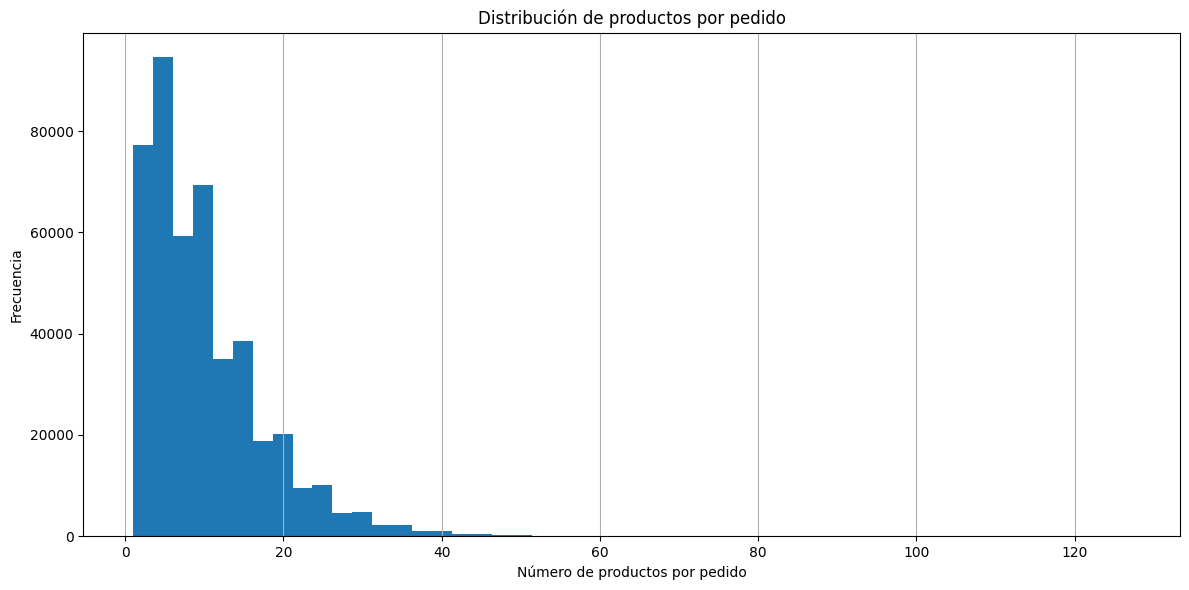

In [ ]:
plt.figure(figsize=(12, 6))
products_by_order.hist(bins=50)

plt.title('Distribución de productos por pedido')
plt.xlabel('Número de productos por pedido')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones
- Las personas compran mínimo un producto por pedido y máximo 127.
- En promedio, las personas compran entre 8 y 9 productos por pedido.
- La mayoría de los pedido tienen menos de 20 productos.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [ ]:
reorders = ord_products[ord_products["reordered"] == 1]  # Productos que han sido comprados más de una vez

In [ ]:
top_20_reorders = (reorders.groupby("product_id")["order_id"].count().reset_index())
top_20_reorders.columns = ['product_id', 'reordered']
top_20_reorders2 = top_20_reorders.sort_values('reordered', ascending=False)

In [ ]:
reorders_names = top_20_reorders2.merge(products[['product_id', 'product_name']],
                                  on='product_id',
                                  how='left')

In [ ]:
print(reorders_names[['product_id', 'product_name']].head(20))

    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        27845        Organic Whole Milk
7        47626               Large Lemon
8        27966       Organic Raspberries
9        16797              Strawberries
10       26209                     Limes
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       49683            Cucumber Kirby
15       28204        Organic Fuji Apple
16        8277  Apple Honeycrisp Organic
17       39275       Organic Blueberries
18        5876             Organic Lemon
19       49235       Organic Half & Half


Escribe aquí tus conclusiones
- Los primeros 6 productos de los top 20 de recompra son los mismos que el top 20 de productos comprados.
- Producto nuevo en este ranking solo esta Organic Half & Half que quito a Organic Grape Tomatoes con respeto el ranking de productos más comprados.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [ ]:
total_orders= orders['order_number'].sum()
print(total_orders)

8217649


In [ ]:
portion_products = pop_products.copy()    # Para no alterar pop_products
portion_products['portion_ordered'] = (portion_products['order_count'] / total_orders)*100

In [ ]:
portion_names = portion_products.merge(products[['product_id', 'product_name']],
                                               on='product_id',
                                               how='left')
print(portion_names[['product_id', 'product_name','portion_ordered']])

       product_id                                       product_name  \
0           24852                                             Banana   
1           13176                             Bag of Organic Bananas   
2           21137                               Organic Strawberries   
3           21903                               Organic Baby Spinach   
4           47209                               Organic Hass Avocado   
...           ...                                                ...   
45568        5836                       Arctic D Cod Liver Oil Lemon   
45569       43573                                     Whisk- 10 Inch   
45570       43570                                       Queso Cotija   
45571       36174                                  Whole Pinto Beans   
45572       41403  Extra Rich & Thick Spaghetti Sauce Spices & Se...   

       portion_ordered  
0             0.803758  
1             0.648567  
2             0.450725  
3             0.413391  
4         

Escribe aquí tus conclusiones
- Ningún producto llega a 1% de participación de las ventas.
- Es normal que las bananas sean las más vendidas ya que lideran todos los rankings que hemos analizado.
- Muchos productos tienen una participación del 0.000012% por lo que se puede analizar su continuidad de venta para esa inversión redireccionarla a otros productos o a otros modelos de negocio.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?.

4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.

In [ ]:
# Productos repetidos por pedido

orders_users = ord_products.merge(                            # Unir la tabla de order_products con orders
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

# Agrupar por cliente los productos reordenados
proportion_by_users = orders_users.groupby(['user_id']).agg({
'reordered': ['sum'],
'product_id': 'count'
}).reset_index()

proportion_by_users.columns = ['user_id','Reorders','Total_products']
display(proportion_by_users)

,user_id,Reorders,Total_products
0,2,1,26
1,4,0,2
2,5,8,12
3,6,0,4
4,7,13,14
...,...,...,...
149621,206203,6,27
149622,206206,15,21
149623,206207,41,46
149624,206208,87,125


In [ ]:
proportion_by_users['reorder_rate'] = (proportion_by_users['Reorders'] / proportion_by_users['Total_products'])*100
display(proportion_by_users.head())
print(proportion_by_users['reorder_rate'].min())
print(proportion_by_users['reorder_rate'].max())
print(proportion_by_users['reorder_rate'].mean())

,user_id,Reorders,Total_products,reorder_rate
0,2,1,26,3.846154
1,4,0,2,0.000000
2,5,8,12,66.666667
3,6,0,4,0.000000
4,7,13,14,92.857143


0.0
100.0
49.48531736151642


Escribe aquí tus conclusiones
- Hay clientes que su tasa de recompra de productos es 0% por lo que pueden ser que sean clientes nuevos.
- Hay clientes que su tasa de recompra de productos es 100% por lo que son consistentes en sus compras.
- La media de productos recomprados es de 49.49% por lo que los clientes vuelven a comprar la prácticamente la mitad de los productos.


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [ ]:
first_product = ord_products[ord_products["add_to_cart_order"] == 1]

In [ ]:
# Agrupar los productos agregados primero en el carrito por producto
top_first = (first_product.groupby("product_id")["order_id"].count().reset_index())
top_first.columns = ['product_id', 'first_time']
top_first2 = top_first.sort_values('first_time', ascending=False)

In [ ]:
first_names = top_first2.merge(products[['product_id', 'product_name']],
                                  on='product_id',
                                  how='left')
print(first_names.head(20))

    product_id  first_time                 product_name
0        24852       15562                       Banana
1        13176       11026       Bag of Organic Bananas
2        27845        4363           Organic Whole Milk
3        21137        3946         Organic Strawberries
4        47209        3390         Organic Hass Avocado
5        21903        3336         Organic Baby Spinach
6        47766        3044              Organic Avocado
7        19660        2336                 Spring Water
8        16797        2308                 Strawberries
9        27966        2024          Organic Raspberries
10       44632        1914   Sparkling Water Grapefruit
11       49235        1797          Organic Half & Half
12       47626        1737                  Large Lemon
13         196        1733                         Soda
14       38689        1397     Organic Reduced Fat Milk
15       26209        1370                        Limes
16       12341        1340                Hass A

Escribe aquí tus conclusiones
- Aumentaron ligeramente los productos procesados en este ranking con respectos a los anteriores.
- Las bananas son por mucho el producto que primero añaden al carrito los clientes.

### Conclusion general del proyecto:

- Este fue un proyecto desafiante y muy completo para mi ya que había que emplear todas los comandos y funciones vistos a lo largo del sprint.
- Por otro lado, al ser un proyecto dónde se analizaron múltiples datasets considero que es una pizca de los problemas reales que hay que analizar en un trabajo cotidianamente por lo que me sirve para seguir investigando otros datasets y ver las difetentes perspectivs en que se pueden analizar para obtener diferentes indicadores que ayuden a la empresa a obtener mejores beneficios.
- Finalmente, ya introduciendo un poco más de información del proyecto es interesante como se puede analizar el patrón de comportamiento de diferentes personas que seguramente la mayoría ni se conocen entre sí pero con la información obtenida podemos hacer propuestas de nuevos productos o reorganizar las estrátegias de marketing para que se vayan más satisfechos después de ordenar en Instacart en este caso.